In [90]:
import pandas as pd

path = r'C:\Users\USER\Desktop\develop\공모전\data\result_남성_20대_의정부시.csv'
path.replace('\\', '/')
df = pd.read_csv(path)
#print(df.head())
#print('열')
print(df.columns)

# 불필요한 열 제거
df = df.drop(['no', 'ranking', 'isbn13',
              'addition_symbol',
              'vol', 'bookImageURL',
              'bookDtlUrl'], axis=1)

df.head(10)

Index(['no', 'ranking', 'bookname', 'authors', 'publisher', 'publication_year',
       'isbn13', 'addition_symbol', 'vol', 'class_no', 'class_nm',
       'bookImageURL', 'bookDtlUrl', 'loan_count'],
      dtype='str')


,bookname,authors,publisher,publication_year,class_no,class_nm,loan_count
0,안녕이라 그랬어 :김애란 소설,지은이: 김애란,문학동네,2025.0,813.70,문학 > 한국문학 > 소설,2362
1,소년이 온다 :한강 장편소설,지은이: 한강,창비,2014.0,813.62,문학 > 한국문학 > 소설,2309
2,혼모노 :성해나 소설집,지은이: 성해나,창비,2025.0,813.70,문학 > 한국문학 > 소설,1971
3,모순 :양귀자 장편소설,지은이: 양귀자,쓰다,2013.0,813.62,문학 > 한국문학 > 소설,1852
4,절창 :구병모 장편소설,지은이: 구병모,문학동네,2025.0,813.70,문학 > 한국문학 > 소설,1717
5,작별하지 않는다 :한강 장편소설,지은이: 한강,문학동네,2021.0,813.62,문학 > 한국문학 > 소설,1568
6,괴테는 모든 것을 말했다,스즈키 유이 지음 ;이지수 옮김,콘텐츠그룹 포레스트,2025.0,833.60,문학 > 일본문학 > 소설,1564
7,불편한 편의점 :김호연 장편소설,지은이: 김호연,나무옆의자,2021.0,813.70,문학 > 한국문학 > 소설,1562
8,이중 하나는 거짓말 :김애란 장편소설,지은이: 김애란,문학동네,2024.0,813.70,문학 > 한국문학 > 소설,1477
9,홍학의 자리 :정해연 장편소설,지은이: 정해연,문학동네,2021.0,813.70,문학 > 한국문학 > 소설,1468


# EDA

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookname          2000 non-null   str    
 1   authors           2000 non-null   str    
 2   publisher         2000 non-null   str    
 3   publication_year  1995 non-null   float64
 4   class_no          1808 non-null   float64
 5   class_nm          1808 non-null   str    
 6   loan_count        2000 non-null   int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 109.5 KB


In [92]:
'''
for i in df['publication_year']:
    i = str(i)
print(df['publication_year'].info())
'''
#publication_year은 군집화 알고리즘을 쓰면 굳이 범주형으로 안바꿔도 될 듯 함

"\nfor i in df['publication_year']:\n    i = str(i)\nprint(df['publication_year'].info())\n"

In [93]:
# class_no에서 결측치 있는 행은 빼버리기
print('number of NaN in class_no:', df['class_no'].isnull().sum())
df = df.dropna(subset=['class_no'])
print('number of rows after drop rows have NaN:', len(df))
df.head()

number of NaN in class_no: 192
number of rows after drop rows have NaN: 1808


,bookname,authors,publisher,publication_year,class_no,class_nm,loan_count
0,안녕이라 그랬어 :김애란 소설,지은이: 김애란,문학동네,2025.0,813.70,문학 > 한국문학 > 소설,2362
1,소년이 온다 :한강 장편소설,지은이: 한강,창비,2014.0,813.62,문학 > 한국문학 > 소설,2309
2,혼모노 :성해나 소설집,지은이: 성해나,창비,2025.0,813.70,문학 > 한국문학 > 소설,1971
3,모순 :양귀자 장편소설,지은이: 양귀자,쓰다,2013.0,813.62,문학 > 한국문학 > 소설,1852
4,절창 :구병모 장편소설,지은이: 구병모,문학동네,2025.0,813.70,문학 > 한국문학 > 소설,1717


In [94]:
# class_no를 기반으로 클러스터링
print('describe of class_no')
print(df['class_no'].describe())
print()

print('describe of loan_count')
print(df['loan_count'].describe())

describe of class_no
count    1808.000000
mean      661.616906
std       248.064996
min         1.000000
25%       471.000000
50%       813.700000
75%       813.700000
max       999.000000
Name: class_no, dtype: float64

describe of loan_count
count    1808.000000
mean      482.138827
std       219.120173
min       290.000000
25%       342.000000
50%       417.000000
75%       537.000000
max      2362.000000
Name: loan_count, dtype: float64


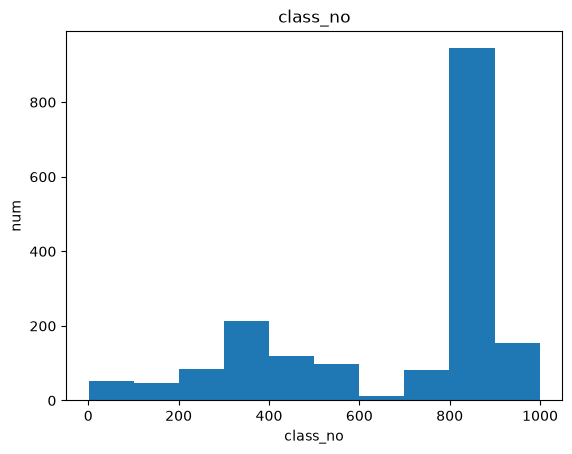

In [95]:
import matplotlib.pyplot as plt

plt.hist(df['class_no'])
plt.xlabel('class_no')
plt.ylabel('num')
plt.title('class_no')
plt.show()

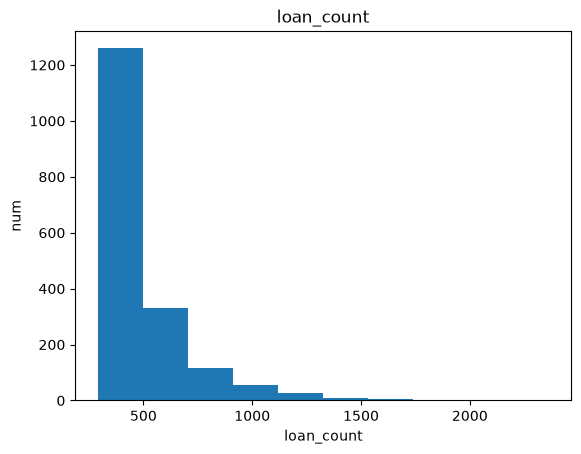

In [96]:
plt.hist(df['loan_count'])
plt.xlabel('loan_count')
plt.ylabel('num')
plt.title('loan_count')
plt.show()

In [97]:
df['loan_count'].info()

<class 'pandas.Series'>
Index: 1808 entries, 0 to 1999
Series name: loan_count
Non-Null Count  Dtype
--------------  -----
1808 non-null   int64
dtypes: int64(1)
memory usage: 28.2 KB


In [98]:
print(df['loan_count'].describe())

count    1808.000000
mean      482.138827
std       219.120173
min       290.000000
25%       342.000000
50%       417.000000
75%       537.000000
max      2362.000000
Name: loan_count, dtype: float64


In [99]:
df['loan_count'].corr(df['class_no'])

np.float64(0.02532188936386468)

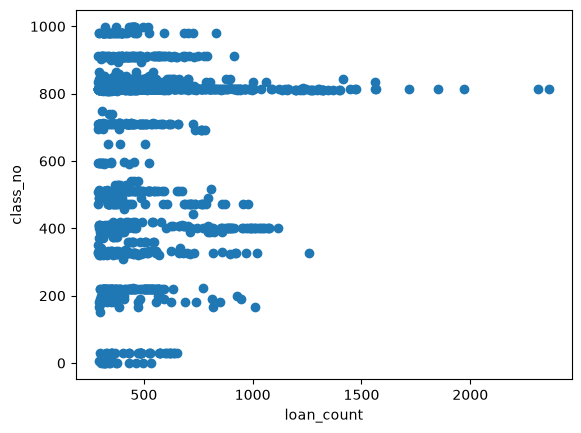

In [100]:
plt.scatter(df['loan_count'], df['class_no'])
plt.xlabel('loan_count')
plt.ylabel('class_no')
plt.show()

- 대출 횟수와 책의 상관관계는 별 상관 없는듯 함
- 일단 수치형 자료만으로 군집 분석 수행

In [101]:
print('before')
print(df.select_dtypes('number').isnull().sum())
df = df.dropna(subset=['publication_year'])
print('\nafter')
print(df.select_dtypes('number').isnull().sum())

before
publication_year    4
class_no            0
loan_count          0
dtype: int64

after
publication_year    0
class_no            0
loan_count          0
dtype: int64


In [102]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=10, random_state=42)
km.fit(df.select_dtypes('number'))

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](10, 3)",

In [ ]:
print(km.labels_)

import numpy as np
print(np.unique(km.labels_, return_counts=True))
# 레이블은 0~9

[2 2 2 ... 3 9 9]
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([384, 122,  41, 130,  60, 105,  76,  53, 174, 659]))
